In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

#not in scope of this course
from torchvision.datasets import MNIST
import torchvision.transforms as T
from torch.utils.data import DataLoader

In [ ]:
train_dataset = MNIST("/", download = True, train = True, transform = T.ToTensor())
test_dataset = MNIST("/", download = True, train = False, transform = T.ToTensor())

100%|██████████| 9912422/9912422 [00:00<00:00, 98996624.16it/s]


Extracting /MNIST/raw/train-images-idx3-ubyte.gz to /MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 48727149.57it/s]


Extracting /MNIST/raw/train-labels-idx1-ubyte.gz to /MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 30606841.93it/s]


Extracting /MNIST/raw/t10k-images-idx3-ubyte.gz to /MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 5126622.38it/s]


Extracting /MNIST/raw/t10k-labels-idx1-ubyte.gz to /MNIST/raw



In [ ]:
bs = 32
train_loader = DataLoader(train_dataset, batch_size = bs)
test_loader = DataLoader(test_dataset, batch_size = bs)

In [ ]:
batch = next(iter(train_loader))

In [ ]:
print(batch[0].shape)

torch.Size([32, 1, 28, 28])


In [ ]:
class myNN(nn.Module):
  def __init__(self, ni, nh1, nh2, no):
    super().__init__()
    self.l1 = nn.Linear(ni, nh1)
    self.l2 = nn.Linear(nh1, nh2)
    self.l3 = nn.Linear(nh2, no)

  def forward(self, x):
    x = self.l1(x)
    x = F.relu(x)
    x = self.l2(x)
    x = F.sigmoid(x)
    x = self.l3(x)
    # no softmax
    return x

In [ ]:
device = torch.device('cuda:0')
ni = 784 # next layer generally should be around 78400, 7 AKA minus or plus 2 exponents
nh1 = 200
nh2 = 100
no = 10
lr = 1e-2 # 1e-2 = 0.001
mm = 0.5
epochs = 10
model = myNN(ni, nh1, nh2, no)
opt = optim.SGD(model.parameters(),lr=lr,momentum=mm)
model.to(device)

myNN(
  (l1): Linear(in_features=784, out_features=200, bias=True)
  (l2): Linear(in_features=200, out_features=100, bias=True)
  (l3): Linear(in_features=100, out_features=10, bias=True)
)

Epoch 1 loss is: 0.07623316379363339
Epoch 2 loss is: 0.07311546263856192
Epoch 3 loss is: 0.07011793543721238
Epoch 4 loss is: 0.06730282369454701
Epoch 5 loss is: 0.0646388360420242
Epoch 6 loss is: 0.062106568090307214
Epoch 7 loss is: 0.05970453511700034
Epoch 8 loss is: 0.057437113066700594
Epoch 9 loss is: 0.05526711618769914
Epoch 10 loss is: 0.05321616695498427
0.9865999817848206


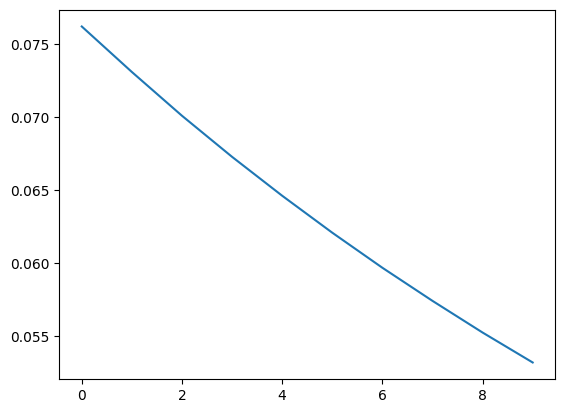

In [ ]:
ls = []
for i in range(epochs):
  batch_losses = 0
  correct = 0

  for batch in (train_loader):
    X = batch[0]
    y = batch[1]
    X = X.view(-1, X.shape[1] * X.shape[2] * X.shape[3]) # shape 1 and 2 and 3 represent number of channels, number of row, and number of columns respectively.
    X = X.to(device) # move the data and labels to the gpu
    y = y.to(device)

    yhat = model.forward(X)
    loss = F.cross_entropy(yhat, y)
    loss.backward()
    opt.step()
    opt.zero_grad()

    batch_losses += loss.item()
    pred = torch.argmax(yhat, axis=1)
    correct += torch.sum(pred == y)

  ls.append(batch_losses / len(train_loader))
  print(f'Epoch {i + 1} loss is: {ls[i]}')

print('The training accuracy is: ',(correct / len(train_dataset)).item())
plt.plot(ls)

In [ ]:
correct = 0
for batch in (test_loader):
  X = batch[0]
  y = batch[1]
  X = X.view(-1, X.shape[1] * X.shape[2] * X.shape[3]) # shape 1 and 2 and 3 represent number of channels, number of row, and number of columns respectively.
  X = X.to(device) # move the data and labels to the gpu
  y = y.to(device)

  yhat = model(X)
  pred = torch.argmax(yhat, axis=1)
  correct += torch.sum(pred == y)

print(f'The testing accuracy is {correct / len(test_dataset)}')

The testing accuracy is 0.974399983882904
